## Importing Packages and Data

In [1]:
import os
import warnings
import glob
import numpy as np
import pandas as pd
import scanpy as sc
import bbknn
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sb
from matplotlib import rcParams, colors

from plot_utils import *

mpl.rcParams['pdf.fonttype'] = 42
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=90, frameon=False)
warnings.filterwarnings('ignore')

/home/yerrar/.conda/envs/lifestyle_env_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
allpbmcs = sc.read('/projects/USERS/athib/Lifestyle/DeidentifiedObjects/Lifestyle_scRNA.h5ad')
allpbmcs

AnnData object with n_obs × n_vars = 119341 × 31720
    obs: 'SampleID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Annotation', 'Lineage Annotation', 'Group', 'Sex', 'Age', 'Ancestry', 'Body Mass Index (BMI)', 'Total Mass (kg)', 'Lean Mass (kg)', 'Fat Mass (kg)', 'VO2 (mL/kg/min)', 'PPT', 'HBA1C (%)', 'HOMA-IR', 'MATSUDA index', 'RKE60', 'Triglyceride (mg/dL)', 'C-reactive protein', 'ROS byproduct - Isoprostane (pg/mL)', 'Batch'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Annotatation_colors', 'Annotation_colors', 'Batch_colors', 'Final_GroupAnnotation_colors', 'Final_annotation_v2_colors', 'Final_annotation_v2_revised_colors', 'GroupAnnotation_colors', 'Lineage Annotation_colors', 'OldAnnotations_colors', 'SampleID_colors', 'dendrogram_leiden', 'hvg',

## Figure 1b

In [15]:
metricdata = pd.read_excel("/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/Table1_Metadata.xlsx", sheet_name=0)

In [16]:
metricdata.index = metricdata['Sample ID']
pre = metricdata.loc[metricdata['Group'] == "Pre",'Sample ID'].values
post = metricdata.loc[metricdata['Group'] == "Post",'Sample ID'].values


<Axes: title={'center': 'Insulin Sensitivity'}, ylabel='MATSUDA index'>

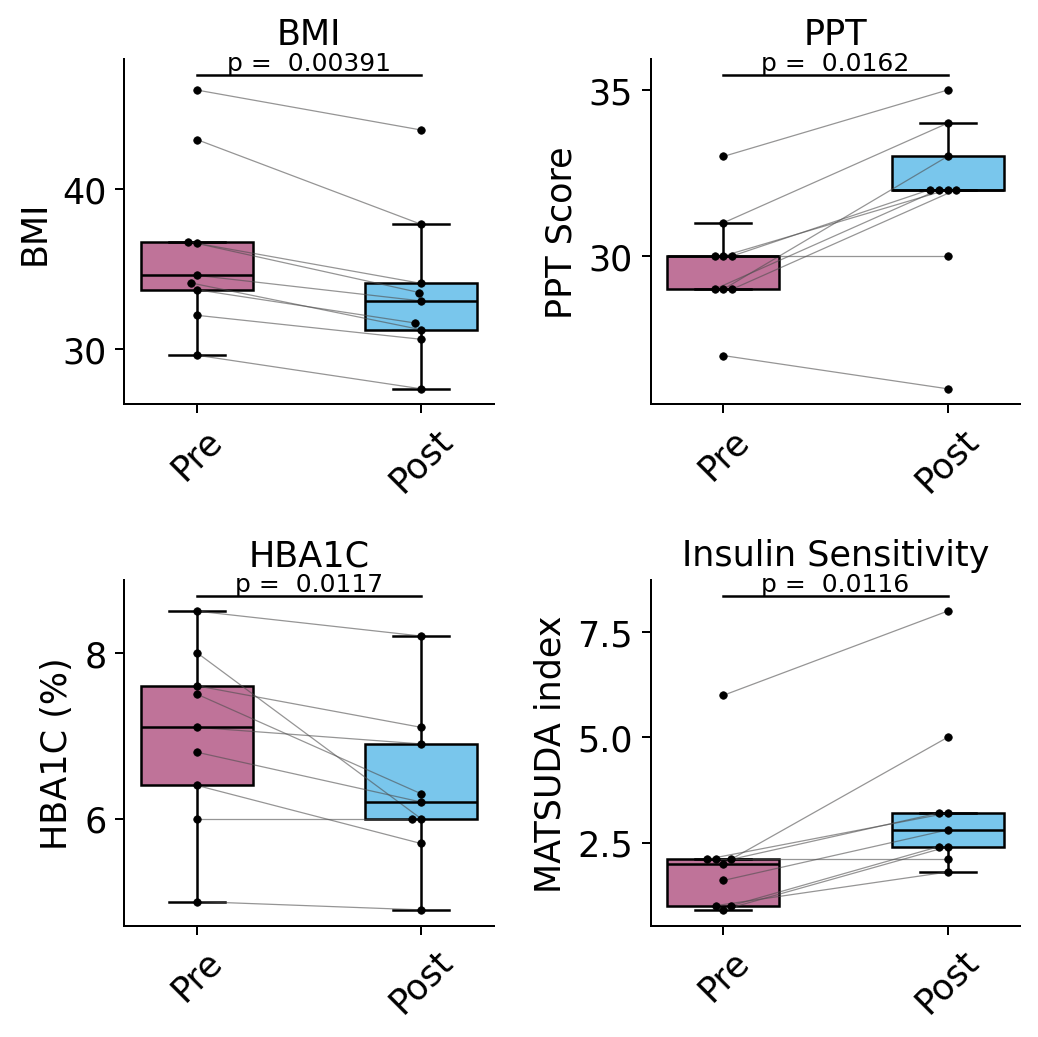

In [17]:
metrics_fig, metrics_axes = plt.subplots(2,2, figsize=(6, 6))

plotBoxplot(metricdata.loc[pre,'Body Mass Index (BMI)'].values, metricdata.loc[post,'Body Mass Index (BMI)'].values, 
               title='BMI', ylabel='BMI', figsize=(3,3),existingaxes=metrics_axes[0][0])

plotBoxplot(metricdata.loc[pre,'PPT'].values, metricdata.loc[post,'PPT'].values, 
               title='PPT', ylabel='PPT Score', figsize=(3,3), existingaxes=metrics_axes[0][1])

plotBoxplot(metricdata.loc[pre,'HBA1C (%)'].values, metricdata.loc[post,'HBA1C (%)'].values, 
               title='HBA1C', ylabel='HBA1C (%)', figsize=(3,3), existingaxes=metrics_axes[1][0])

plotBoxplot(metricdata.loc[pre,'MATSUDA index'].values, metricdata.loc[post,'MATSUDA index'].values, 
               title='Insulin Sensitivity', ylabel='MATSUDA index', figsize=(3,3), existingaxes=metrics_axes[1][1])


## Figure 1c

ROS vs HBA1C
SignificanceResult(statistic=0.6445960519257856, pvalue=0.0038784865285760857)
PearsonRResult(statistic=0.687544002117262, pvalue=0.00161518473143382)


<Figure size 360x360 with 0 Axes>

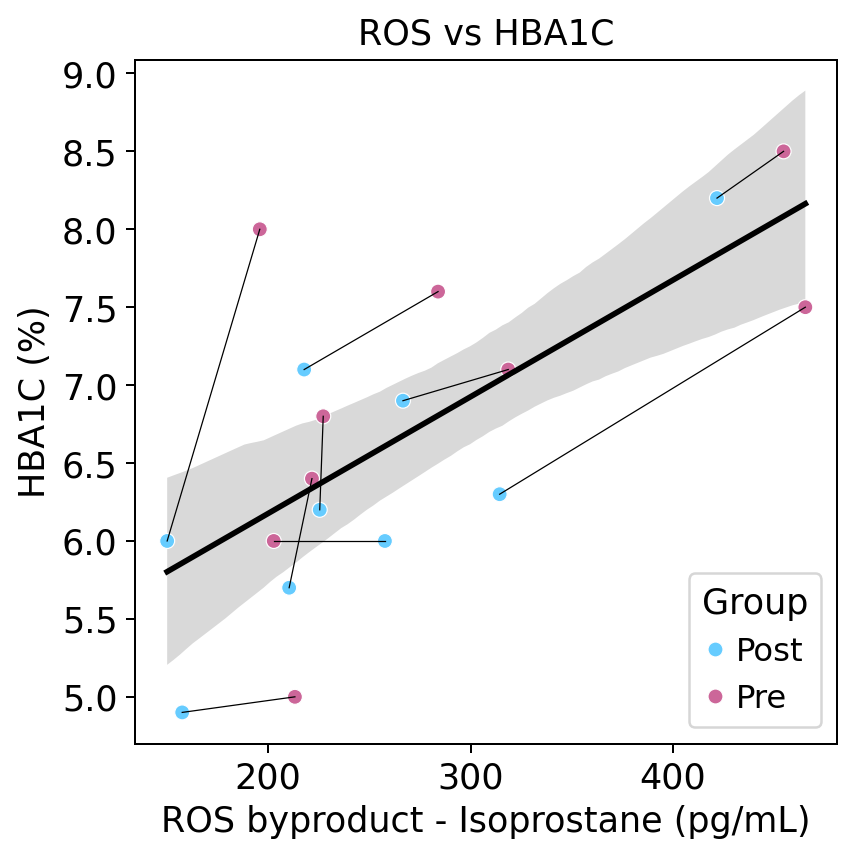

In [18]:
fig = plt.figure()
fig = plotCorrelation(metricdata, 'ROS byproduct - Isoprostane (pg/mL)', 'HBA1C (%)', 'Group', 'ROS vs HBA1C', palette={"Post":"#66CCFF","Pre":"#CC6699"})


## Figure 1d

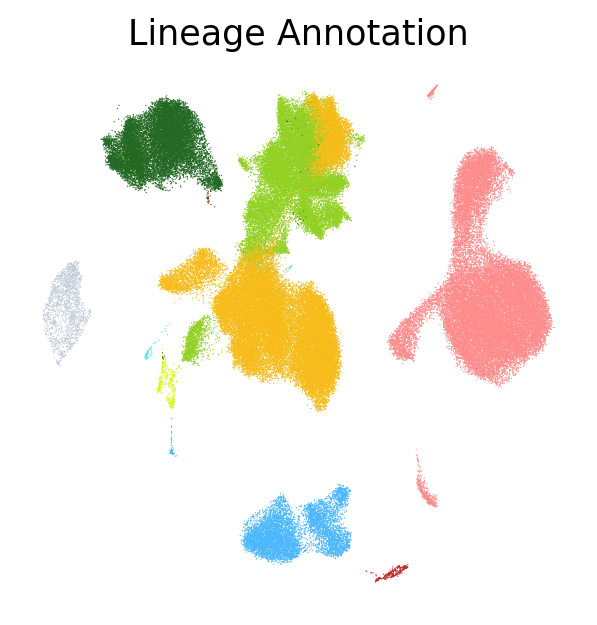

In [20]:
color_palette = dict()
color_palette['CD4+ T'] = '#f7bc19ff'
color_palette['Memory B'] = '#233591ff'
color_palette['HSPC'] = '#65ebe2ff'
color_palette['Erythroblast'] = '#bf2c2cff'
color_palette['Proliferating'] = '#d3fc03ff'
color_palette['B'] = '#4ab7ffff'
color_palette['Treg'] = '#ff9100ff'
color_palette['Myeloid'] = '#ff8c8cff'
color_palette['MGK'] = '#c3cddbff'
color_palette['CD8+ and γδ T'] = '#92d124ff'
color_palette['NK'] = '#236924ff'
color_palette['ILC2-like'] = '#8c390dff'

sc.pl.umap(allpbmcs, color=['Lineage Annotation'], legend_loc=None, palette=color_palette, save='RNA_UMAP.pdf')

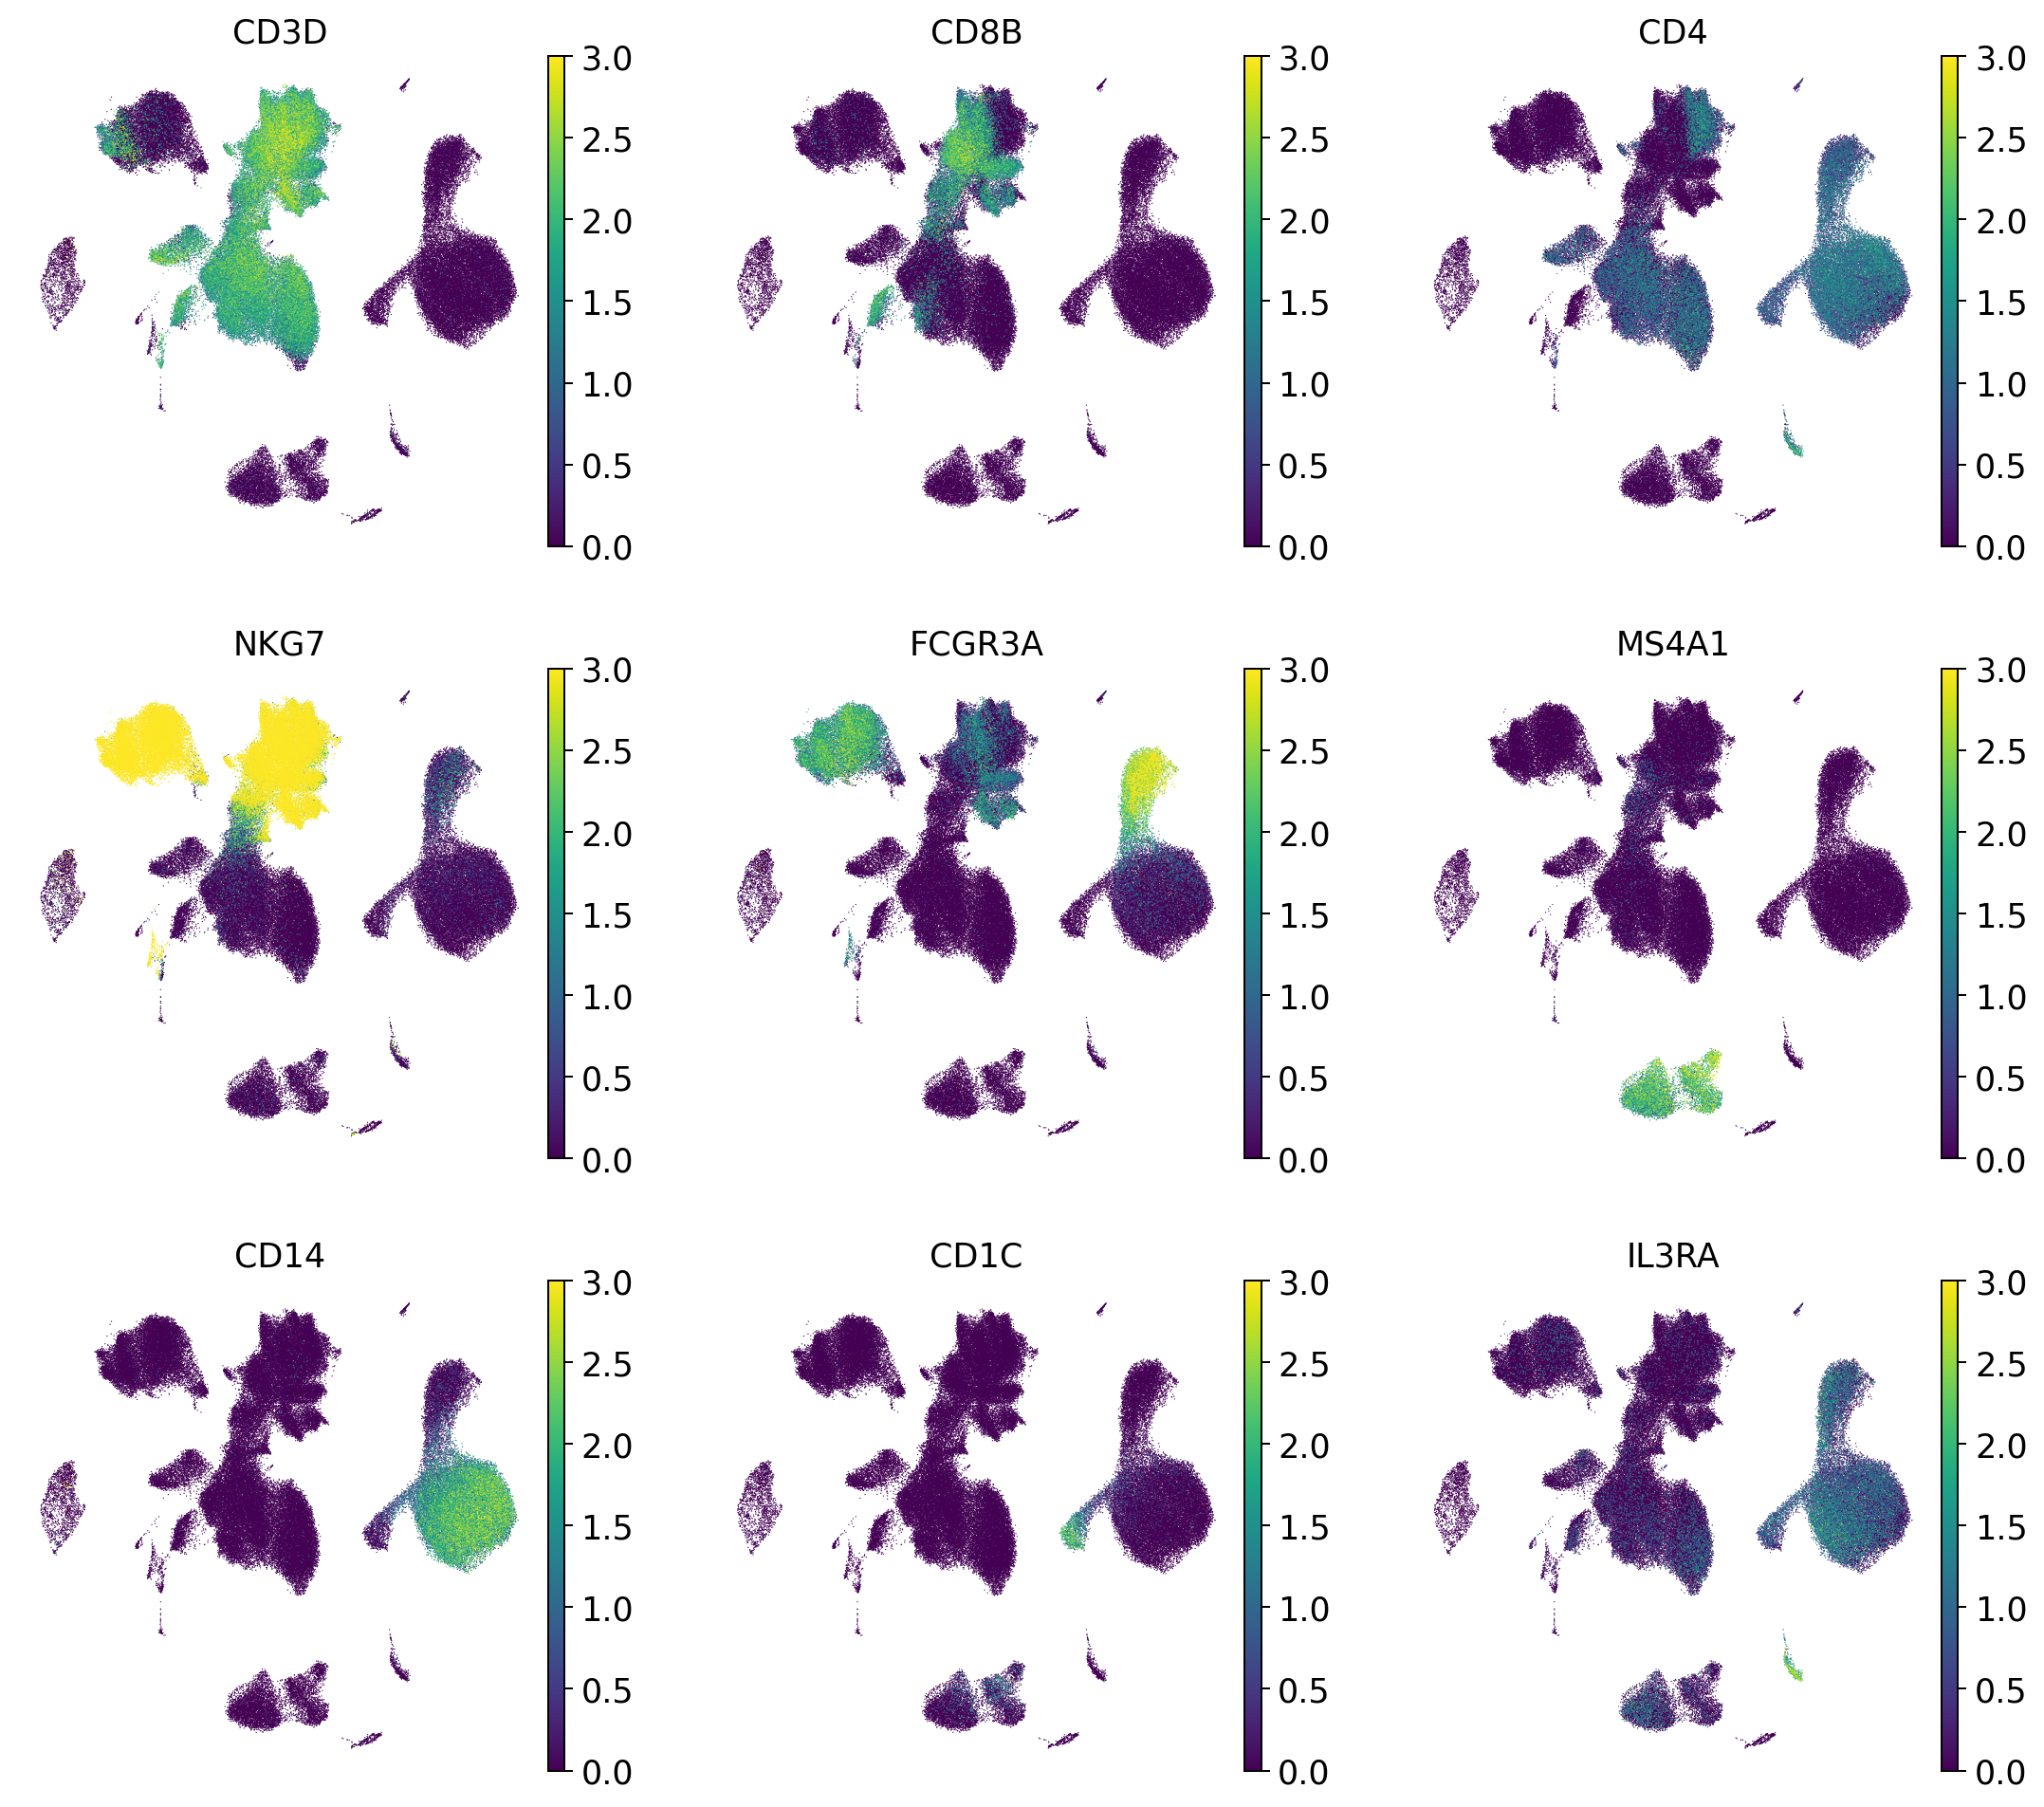

In [22]:
sc.pl.umap(allpbmcs, color=['CD3D', 'CD8B','CD4',
                                 'NKG7', 'FCGR3A', 'MS4A1',
                                 'CD14', 'CD1C', 'IL3RA',  ], ncols=3, legend_loc=None, palette=color_palette,
           vmax=3)




## Figure 1e

In [23]:
deg_pbmcs = pd.read_csv('/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Lineage_Annotation/DE_all_pbmcs.csv')
deg_pbmcs = deg_pbmcs.sort_values(by='FDR', ascending=True)

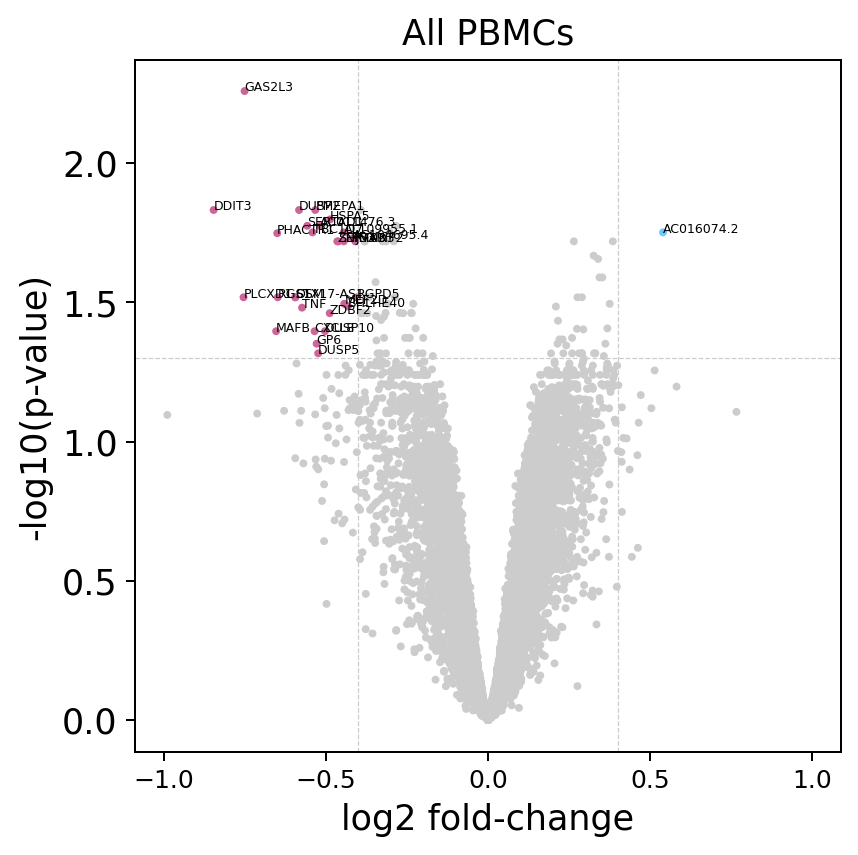

In [25]:
sc.set_figure_params(dpi=90)
fig = plot_volcano(
    deg_pbmcs,
    title="All PBMCs",
    logfc=0.4,
    adjustp=0.05,
    label_fc=0.4,
    label_p=0.05,
)
plt.show()

## Figure 1f

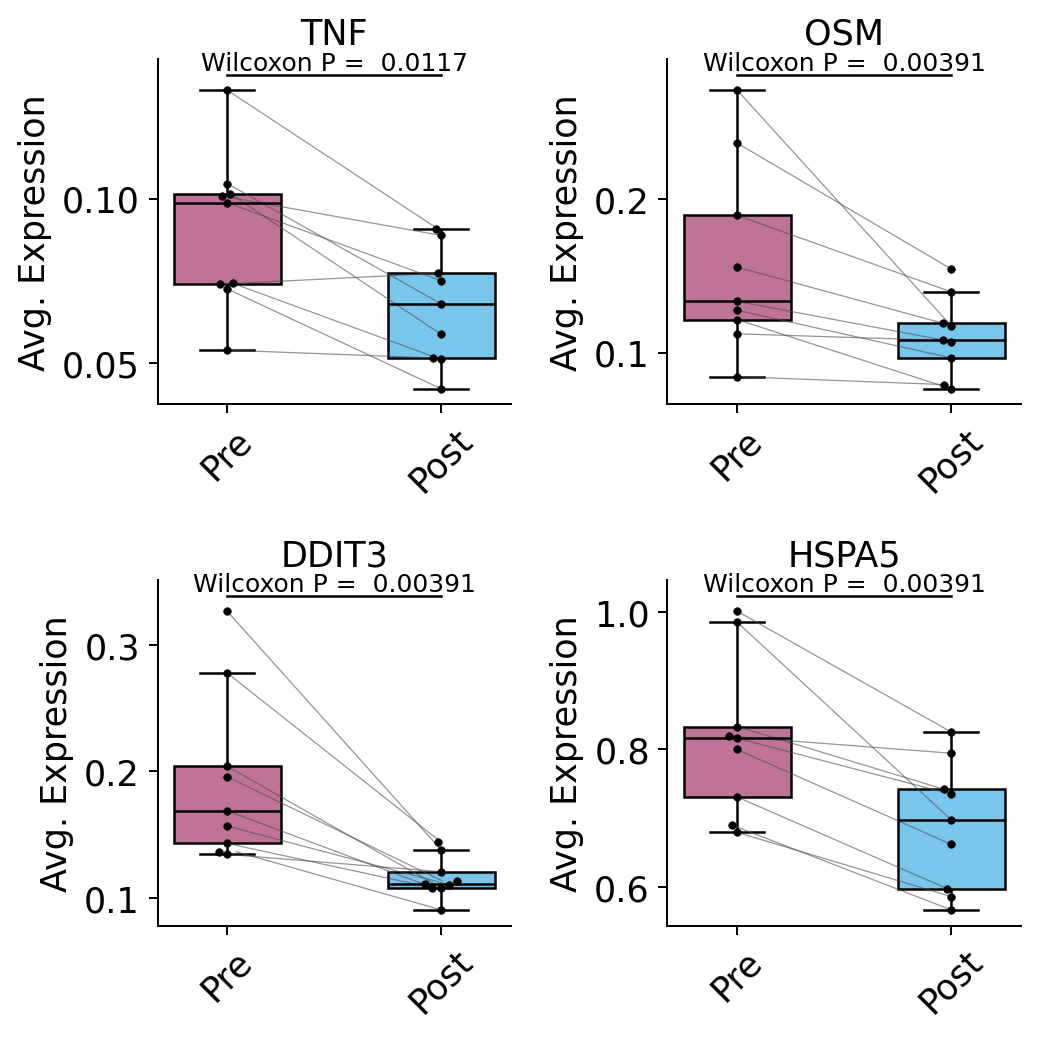

In [27]:
sc.set_figure_params(dpi=90)
pairs = getPairs()

allpbmcs_raw = allpbmcs.raw.to_adata().copy()
curfig = plotExpressionMultiple(allpbmcs_raw, ['TNF', 'OSM', 'DDIT3', 'HSPA5'], ncols=2)

## Figure 1g

In [ ]:
%%R
library(GSEABase)
library(fgsea)
library(msigdb)
library(ggplot2)

msigdb.hs <- getMsigdb(org = "hs", id = "SYM", version = "7.4")
msigdb.hs <- appendKEGG(msigdb.hs)

t_ctype <- lapply(msigdb.hs, GSEABase::collectionType)
t_gsc <- msigdb.hs[
  sapply(t_ctype, GSEABase::bcCategory) %in% "h" |
    sapply(t_ctype, GSEABase::bcSubCategory) %in% c("CP:KEGG", "CP:PID")
]
msigdb_ids <- geneIds(t_gsc)
all_msigdb <- geneIds(msigdb.hs)

exhaust_sets <- c(
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_UP",
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_DN"
)
missing <- setdiff(exhaust_sets, names(all_msigdb))
if (length(missing) > 0) {
  warning("These gene sets were not found in msigdb.hs: ", paste(missing, collapse = ", "))
}
msigdb_exhaust <- all_msigdb[intersect(exhaust_sets, names(all_msigdb))]

sen_genes_df <- read.csv("./Final_Files/GSEA_Signatures/SenMayo.csv")
Sen_Mayo <- list(Sen_Mayo = unique(as.character(sen_genes_df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveCD4_vsOtherCD4_signature.csv")
NaiveCD4 <- list(NaiveCD4 = unique(as.character(df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveB_vsOtherB_signature.csv")
NaiveB <- list(NaiveB = unique(as.character(df$gene)))
all_pathways <- c(msigdb_ids, msigdb_exhaust, Sen_Mayo, NaiveCD4, NaiveB)

degeneresult <- read.csv('./Final_Files/DEG_Results/Lineage_Annotation/DE_all_pbmcs.csv', stringsAsFactors = FALSE)
degeneresult <- degeneresult[!duplicated(degeneresult$X), ]
degeneresult$PValue <- suppressWarnings(as.numeric(degeneresult$PValue))
degeneresult$logFC <- suppressWarnings(as.numeric(degeneresult$logFC))
degeneresult <- degeneresult[!is.na(degeneresult$PValue) & !is.na(degeneresult$logFC), ]
degeneresult$PValue[degeneresult$PValue <= 0] <- 1e-300
degeneresult$Score <- -log(degeneresult$PValue) * sign(degeneresult$logFC)
degeneresult <- degeneresult[is.finite(degeneresult$Score), ]
de_ordered <- degeneresult[order(degeneresult$Score, decreasing = TRUE), ]
de_ordered_genes <- setNames(de_ordered$Score, de_ordered$X)

set.seed(929)
fgsea_res <- fgseaMultilevel(pathways = all_pathways, stats = de_ordered_genes)

fgsea_res$leadingEdge <- sapply(fgsea_res$leadingEdge, paste, collapse = ",")
fgseaRes_sorted <- fgsea_res %>% arrange(padj)
head(fgseaRes_sorted, 50)

fgseaRes_sorted <- fgsea_res %>% arrange(NES)
head(fgseaRes_sorted, 50)

print(fgsea_res[fgsea_res$pathway == "HALLMARK_TNFA_SIGNALING_VIA_NFKB", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_TNFA_SIGNALING_VIA_NFKB"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

print(fgsea_res[fgsea_res$pathway == "HALLMARK_UNFOLDED_PROTEIN_RESPONSE", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_UNFOLDED_PROTEIN_RESPONSE"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_UNFOLDED_PROTEIN_RESPONSE",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

## Figure 1h

In [28]:
import glob
import os
files = glob.glob("/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Lineage_Annotation/DE_*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    source = os.path.splitext(os.path.basename(f))[0].split("DE_", 1)[1]
    df['source'] = source
    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)
merged.rename(columns={"Unnamed: 0": "Gene"}, inplace=True)

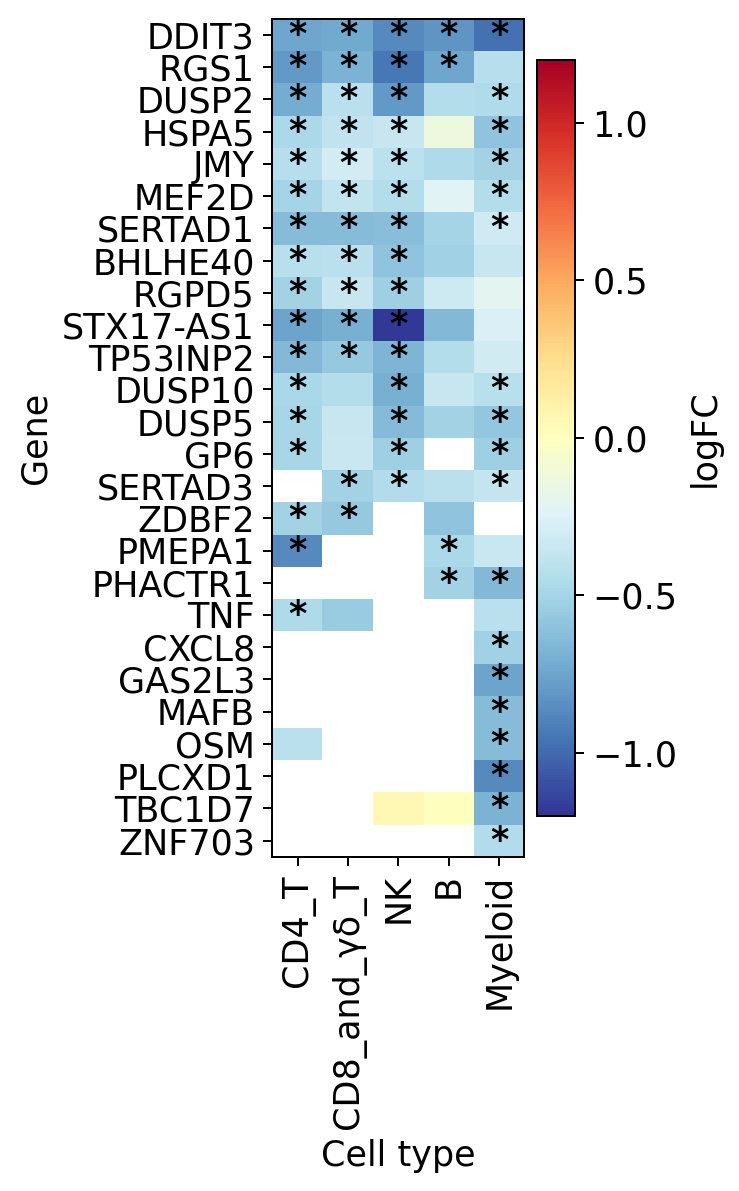

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

cell_types = ['CD4_T','CD8_and_γδ_T','NK','B','Myeloid',]

pbmcs_deg = pd.read_csv("/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Lineage_Annotation/DE_all_pbmcs.csv")
pbmcs_deg.rename(columns={"Unnamed: 0": "Gene"}, inplace=True)
sig_down = (
    pbmcs_deg
    .loc[(pbmcs_deg["FDR"] < 0.05) & (pbmcs_deg["logFC"] < -0.40)]
    .sort_values("logFC")
)
genes_to_plot = sig_down["Gene"].tolist()

subset = merged.loc[
    merged["Gene"].isin(genes_to_plot) &
    merged["source"].isin(cell_types),
    ["Gene","source","logFC","FDR"]
]

heatmap_data = subset.pivot(index="Gene", columns="source", values="logFC")

sig_mask = (
    subset
    .assign(sig = subset["FDR"] < 0.05)
    .pivot(index="Gene", columns="source", values="sig")
)

# Drop AC‐prefix genes
keep = ~heatmap_data.index.str.startswith(("AC", "AL"))
heatmap_data = heatmap_data.loc[keep]
sig_mask     = sig_mask.loc[keep]

heatmap_data = heatmap_data[cell_types]
sig_mask     = sig_mask[cell_types]

sig_mask = sig_mask.fillna(False)

sig_count   = sig_mask.sum(axis=1).rename("n_sig")
sig_pattern = sig_mask.astype(int)
order_df    = pd.concat([sig_count, sig_pattern], axis=1)

order_cols = ["n_sig"] + cell_types
order_df   = order_df.sort_values(by=order_cols, ascending=[False]*len(order_cols))
ordered_genes = order_df.index.tolist()

heatmap_data = heatmap_data.loc[ordered_genes]
sig_mask     = sig_mask.loc[ordered_genes]

fig, ax = plt.subplots(figsize=(4, len(ordered_genes)*0.25), constrained_layout=True)
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlBu_r', vmin=-1.2, vmax=1.2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('logFC')

ax.set_xticks(range(len(cell_types)))
ax.set_xticklabels(cell_types, rotation=90)
ax.set_yticks(range(len(ordered_genes)))
ax.set_yticklabels(ordered_genes)
ax.set_xlabel('Cell type')
ax.set_ylabel('Gene')
ax.grid(False)

for i, gene in enumerate(ordered_genes):
    for j, ct in enumerate(cell_types):
        if sig_mask.loc[gene, ct]:
            ax.text(j, i, '*', ha='center', va='center', color='black', fontweight='bold')

plt.show()

## Figure 1i

In [ ]:
pathwaygenes    = pd.read_csv('./data/MitoPathwayGenes.csv')
mitoscore_pbmcs = pd.read_csv('./data/PBMC_Corrected_2_datalong.csv').dropna()

In [ ]:
def getMitoScoreStatsTable(mitoscores, pairs, pathwaygenes):
    tissues      = mitoscores['Tissue'].unique()
    mitopathways = mitoscores['Pathway'].unique()
    statstable   = {'Cell Type': [], 'Pathway': [], 'Mean Pre': [], 'Mean Post': [],
                    'Wilcoxon P': [], 'MW P': [], 'Diff': []}

    for curcelltype in tissues:
        for curpathway in mitopathways:
            if sum(pathwaygenes['Pathway'] == curpathway) < 0:
                continue
            cursel = mitoscores.loc[
                (mitoscores['Tissue'] == curcelltype) & (mitoscores['Pathway'] == curpathway)
            ]
            g1, g2 = [], []
            for cur in pairs:
                g1val = cursel.loc[cursel['Group'] == cur, 'score']
                g2val = cursel.loc[cursel['Group'] == pairs[cur], 'score']
                if len(g1val) == 1 and len(g2val) == 1:
                    g1.append(g1val)
                    g2.append(g2val)
            try:
                statstable['Cell Type'].append(curcelltype)
                statstable['Pathway'].append(curpathway)
                statstable['Mean Pre'].append(np.mean(g1))
                statstable['Mean Post'].append(np.mean(g2))
                statstable['Wilcoxon P'].append(stats.wilcoxon(g1, g2)[1][0])
                statstable['MW P'].append(stats.mannwhitneyu(g1, g2)[1][0])
                statstable['Diff'].append(np.mean(g2) - np.mean(g1))
            except:
                print(g1, ":", g2)

    statstable = pd.DataFrame(statstable)
    statstable['Wilcoxon padj'] = multitest.fdrcorrection(statstable['Wilcoxon P'])[1]
    statstable['MW padj']       = multitest.fdrcorrection(statstable['MW P'])[1]
    return statstable

In [ ]:
def getBoxplot(scores, tissue, pathway, pairs, title=None, existingaxes=None):
    curscores = scores[(scores['Tissue'] == tissue) & (scores['Pathway'] == pathway)]
    g1, g2 = [], []
    for curpair in pairs:
        g1.append(curscores[curscores['Group'] == curpair]['score'].values[0])
        g2.append(curscores[curscores['Group'] == pairs[curpair]]['score'].values[0])
    if title is None:
        title = pathway
    plotBoxplot(g1, g2, title=title, figsize=(3, 3), ylabel='mtPPS Score', existingaxes=existingaxes)

In [ ]:
pbmcscores = getMitoScoreStatsTable(mitoscore_pbmcs, getPairs(), pathwaygenes)
pbmcscores['-log10Pvalue'] = -np.log10(pbmcscores['Wilcoxon P'])

In [ ]:
ax = pbmcscores.sort_values('MW P')[:10].plot.bar(
    x='Pathway', y='-log10Pvalue', figsize=(3, 3)
)
plt.ylabel('-log10 Wilcoxon P-value')
plt.grid(False)
plt.title('Top 10 Pathways')
plt.tight_layout()
ax.get_figure().savefig('./Figures/MitoScoring_Top10.pdf')

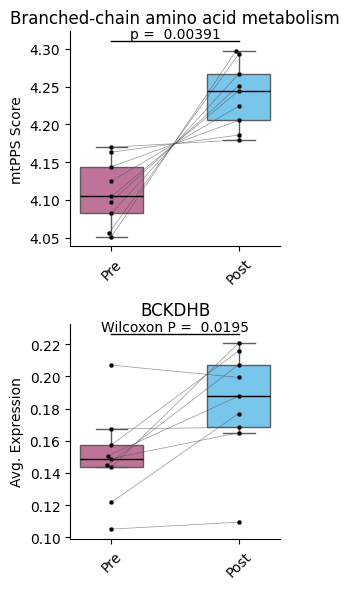

In [12]:
mtPPS_fig, mtPPS_axes = plt.subplots(2, 1, figsize=(3, 6))

getBoxplot(mitoscore_pbmcs, 'PBMC', 'Branched-chain amino acid metabolism',
           getPairs(), existingaxes=mtPPS_axes[0])
plotExpression(allpbmcs_raw, getPairs(), ['BCKDHB'],
               title='BCKDHB', figsize=(3, 3), existingaxes=mtPPS_axes[1])

mtPPS_fig.savefig('./Figures/AllPBMCs_mtPPS.pdf')

## Figure 1j

In [ ]:
allpbmc_gsea = pd.read_csv('./Final_Files/GSEA_Results_v2/GSEA_DE_all_pbmcs.csv')

leadingedges = {
    'TNF_LeadingEdge':    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
}

for colname, pathway in leadingedges.items():
    genes = allpbmc_gsea.loc[allpbmc_gsea['pathway'] == pathway, 'leadingEdge'].values[0].split(',')
    curmeans = getMeanPerSample(allpbmcs_raw, genes)
    curmeans.index = curmeans['Names_groups']
    metricdata.loc[curmeans.index, colname] = curmeans['Value']

All PBMCs
SignificanceResult(statistic=np.float64(-0.5211558307533539), pvalue=np.float64(0.026565697103864794))
PearsonRResult(statistic=np.float64(-0.580686170391532), pvalue=np.float64(0.01150815632624144))


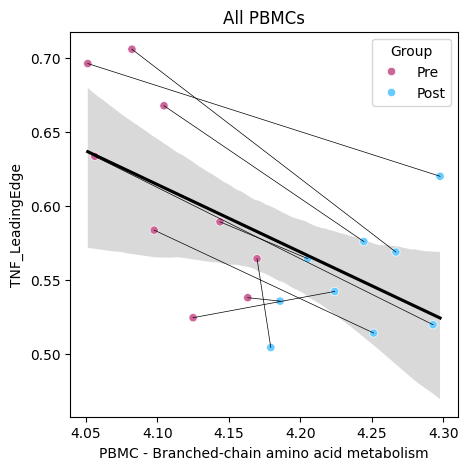

In [77]:
fig = plotCorrelation(metricdata, 'PBMC - Branched-chain amino acid metabolism', 'TNF_LeadingEdge',
                      'Group', 'All PBMCs', palette={"Post": "#66CCFF", "Pre": "#CC6699"})
fig.savefig('./Figures/BCAA_TNF.pdf')